In [10]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

write_output = False

import torch
import rasterio
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt


In [11]:
# 1) Malla 
dx = 250.0
dy = 250.0
dz = 200.0

ncx = 20
ncy = 20
ncz = 20

# Padding 
pad_xy = [1800.0, 1400.0, 1000.0, 700.0, 450.0]

hx = (
    pad_xy[::-1] +          # hacia -X
    [(dx, ncx)] +           # núcleo
    pad_xy                  # hacia +X
)

hy = (
    pad_xy[::-1] +          # hacia -Y
    [(dy, ncy)] +           # núcleo
    pad_xy                  # hacia +Y
)

hz = [
    (dz * 5.0, 5),
    (dz, ncz),
    (dz * 5.0, 5),
]

mesh = TensorMesh([hx, hy, hz], x0=["C", "C", -9000.0])

# Centros de celda
x = mesh.cell_centers[:, 0]
y = mesh.cell_centers[:, 1]
z = mesh.cell_centers[:, 2]

print("shape_cells:", mesh.shape_cells)
print("nC:", mesh.nC)

shape_cells: (30, 30, 30)
nC: 27000


In [12]:
# 2) Topografía

valle_sw = -700.0 * np.exp(
    -((x + 3500.0) / 2800.0) ** 2
    -((y + 3000.0) / 2600.0) ** 2
)

loma_ne = 650.0 * np.exp(
    -((x - 4500.0) / 3200.0) ** 2
    -((y - 3500.0) / 3000.0) ** 2
)

ondulacion_x = 250.0 * np.sin(2 * np.pi * x / 12000.0)
ondulacion_y = 180.0 * np.sin(2 * np.pi * y / 11000.0)

topo_z = valle_sw + loma_ne + ondulacion_x + ondulacion_y



In [13]:
# 3) Modelo MT (conductividad)
# Modelo de 3 capas horizontales (planas, no siguen la topografía)
sigma = np.zeros(mesh.nC)

# Límites de profundidad entre capas (elevación z, misma convención que topo_z)
z_lim1 = -1000.0   # límite capa 1 / capa 2
z_lim2 = -4000.0   # límite capa 2 / capa 3

# Capa 1: desde la topografía hasta z_lim1
layer1 = z > z_lim1
sigma[layer1] = 10.0

# Capa 2: de z_lim1 a z_lim2
layer2 = (z <= z_lim1) & (z > z_lim2)
sigma[layer2] = 0.001

# Capa 3: por debajo de z_lim2
layer3 = z <= z_lim2
sigma[layer3] = 1e-4

# Aire por encima de la topografía
air_cells = z > topo_z
sigma[air_cells] = 1e-8

In [14]:
mesh

TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00

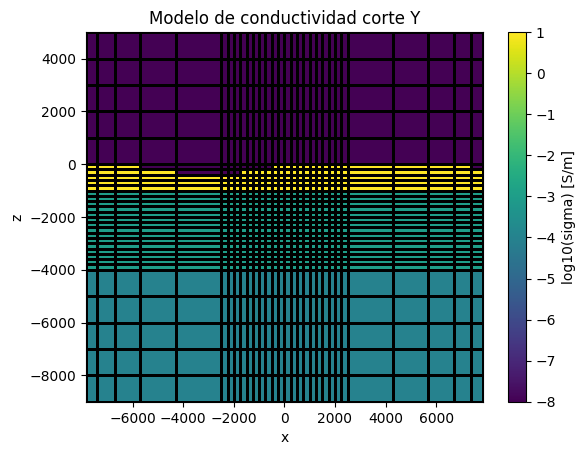

In [15]:
#4) Plot
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="Y")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte Y")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

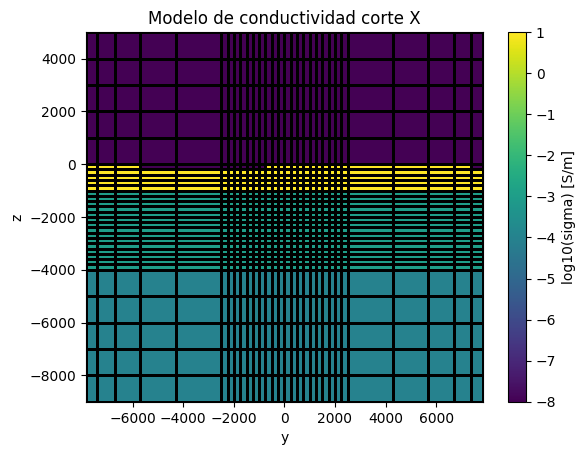

In [16]:
#4) Plot
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="X")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte X")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

In [17]:
# 5) Guardar malla y modelo

mesh.save("mesh_Toy7_MT.json")
np.save("model_Toy7_MT.npy", sigma)